# Ablation study pipeline'u dla autorskiej architektury CNN

Celem eksperymentu jest określenie wpływu poszczególnych elementów pipeline'u przetwarzania i przygotowania danych na skuteczność autorskiej architektury CNN.

W eksperymencie wykorzystano tę samą autorską architekturę `CustomCNN`, która została wcześniej oceniona w oddzielnym screeningu.

Porównane zostaną cztery warianty:

1. `baseline` – naturalny rozkład próbek, bez augmentacji oświetleniowej i bez korekcji gamma,
2. `weighted_sampler` – zastosowanie `WeightedRandomSampler`,
3. `sampler_lighting` – `WeightedRandomSampler` oraz `augmentacja warunków oświetleniowych`,
4. `sampler_lighting_gamma` – `WeightedRandomSampler`, `augmentacja oświetleniowa` oraz `korekcja gamma γ = 1.5`.

Eksperyment ma charakter ablacyjny. Każdy kolejny wariant rozszerza poprzednią konfigurację o jeden element pipeline'u.

In [ ]:
from pathlib import Path
import sys
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.preprocessing import (
    gamma_correction,
    build_preprocessing_train_transform,
    build_preprocessing_eval_transform,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.custom_cnn import (
    create_custom_cnn,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


print(
    "PROJECT_ROOT:",
    PROJECT_ROOT
)

PROJECT_ROOT: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska


In [3]:
METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)


RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)


HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)


CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "custom_cnn_pipeline_ablation"
)


FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)


VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)


TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "DEVICE:",
    DEVICE
)

DEVICE: cpu


## 1. Konfiguracja eksperymentu

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 20
LEARNING_RATE = 1e-3
RANDOM_SEED = 42
GAMMA_VALUE = 1.5

LIGHTING_BRIGHTNESS_RANGE = (
    0.3,
    1.3,
)


LIGHTING_CONTRAST_RANGE = (
    0.8,
    1.2,
)


LIGHTING_PROBABILITY = 0.8


DARK_VARIANTS = [
    "dark_1",
    "dark_2",
    "dark_3",
]


EXPERIMENTS = [
    "baseline",
    "weighted_sampler",
    "sampler_lighting",
    "sampler_lighting_gamma",
]


print(
    "IMAGE_SIZE:",
    IMAGE_SIZE
)

print(
    "BATCH_SIZE:",
    BATCH_SIZE
)

print(
    "EPOCHS:",
    EPOCHS
)

print(
    "LEARNING_RATE:",
    LEARNING_RATE
)

print(
    "GAMMA:",
    GAMMA_VALUE
)

print(
    "LIGHTING_BRIGHTNESS_RANGE:",
    LIGHTING_BRIGHTNESS_RANGE
)

print(
    "LIGHTING_CONTRAST_RANGE:",
    LIGHTING_CONTRAST_RANGE
)

print(
    "LIGHTING_PROBABILITY:",
    LIGHTING_PROBABILITY
)

IMAGE_SIZE: 224
BATCH_SIZE: 32
EPOCHS: 20
LEARNING_RATE: 0.001
GAMMA: 1.5
LIGHTING_BRIGHTNESS_RANGE: (0.3, 1.3)
LIGHTING_CONTRAST_RANGE: (0.8, 1.2)
LIGHTING_PROBABILITY: 0.8


## 2. Wczytanie manifestów i mapowanie klas

In [5]:
train_df = pd.read_csv(
    TRAIN_PATH
)


validation_df = pd.read_csv(
    VALIDATION_PATH
)


test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


NUM_CLASSES = len(
    class_codes
)


print(
    "Liczba klas:",
    NUM_CLASSES
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Definicja transformacji dla poszczególnych wariantów

Wariant `baseline` wykorzystuje wyłącznie podstawowe przygotowanie obrazu.

W wariancie `weighted_sampler` zmieniony zostaje wyłącznie sposób próbkowania danych treningowych.

Wariant `sampler_lighting` dodatkowo wykorzystuje losową zmianę jasności i kontrastu.

Wariant `sampler_lighting_gamma` rozszerza poprzedni wariant o korekcję gamma γ = 1.5.

Wspólną operacją dla wszystkich wariantów pozostaje standardowa transformacja treningowa obejmująca zmianę rozmiaru, losową rotację, konwersję do tensora oraz normalizację.

In [6]:
base_train_transform = (
    build_preprocessing_train_transform(
        method="original",
        image_size=IMAGE_SIZE,
    )
)


gamma_train_transform = (
    build_preprocessing_train_transform(
        method="gamma",
        image_size=IMAGE_SIZE,
        gamma=GAMMA_VALUE,
    )
)


eval_transform = (
    build_preprocessing_eval_transform(
        method="original",
        image_size=IMAGE_SIZE,
    )
)


lighting_augmentation = (
    RandomLightingAugmentation(
        brightness_range=
            LIGHTING_BRIGHTNESS_RANGE,

        contrast_range=
            LIGHTING_CONTRAST_RANGE,

        probability=
            LIGHTING_PROBABILITY,
    )
)


lighting_base_transform = transforms.Compose([
    lighting_augmentation,
    base_train_transform,
])


lighting_gamma_transform = transforms.Compose([
    lighting_augmentation,
    gamma_train_transform,
])

## 4. Kontrola wizualna transformacji

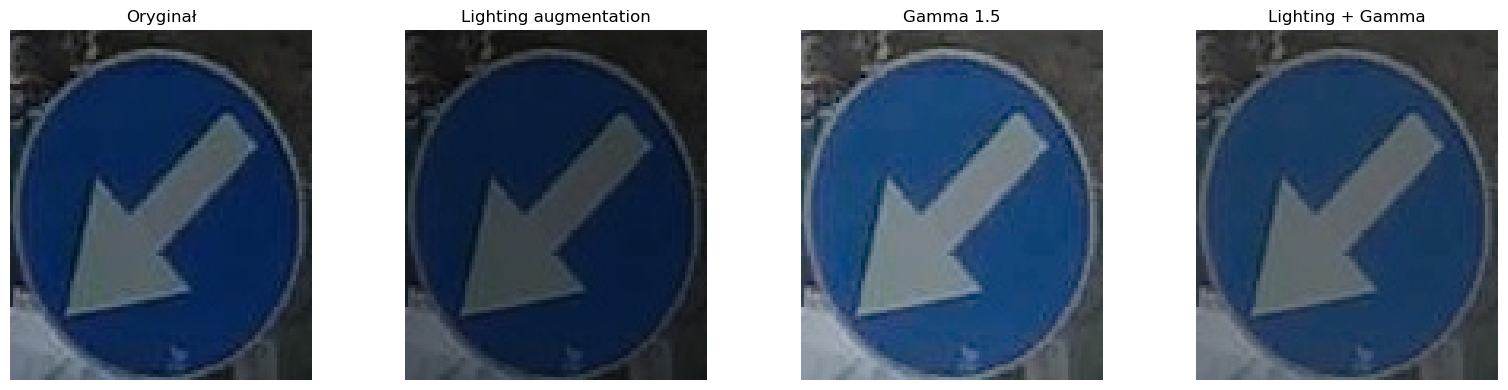

In [7]:
sample_path = Path(
    train_df.iloc[0][
        "path"
    ]
)


sample_image = (
    Image.open(
        sample_path
    )
    .convert("RGB")
)


fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)


axes[0].imshow(
    sample_image
)

axes[0].set_title(
    "Oryginał"
)

axes[0].axis(
    "off"
)


lighting_only = (
    lighting_augmentation(
        sample_image
    )
)


axes[1].imshow(
    lighting_only
)

axes[1].set_title(
    "Lighting augmentation"
)

axes[1].axis(
    "off"
)


gamma_image = (
    gamma_correction(
        sample_image,
        gamma=GAMMA_VALUE,
    )
)


axes[2].imshow(
    gamma_image
)

axes[2].set_title(
    "Gamma 1.5"
)

axes[2].axis(
    "off"
)


lighting_gamma = (
    gamma_correction(
        lighting_only,
        gamma=GAMMA_VALUE,
    )
)


axes[3].imshow(
    lighting_gamma
)

axes[3].set_title(
    "Lighting + Gamma"
)

axes[3].axis(
    "off"
)


plt.tight_layout()
plt.show()

## 5. Funkcja przygotowania DataLoaderów

In [8]:
def build_experiment_loaders(
    experiment_name,
):

    if experiment_name == "baseline":

        train_transform = (
            base_train_transform
        )

        sampler = None


    elif experiment_name == "weighted_sampler":

        train_transform = (
            base_train_transform
        )

        sampler = (
            build_weighted_sampler(
                TRAIN_PATH
            )
        )


    elif experiment_name == "sampler_lighting":

        train_transform = (
            lighting_base_transform
        )

        sampler = (
            build_weighted_sampler(
                TRAIN_PATH
            )
        )


    elif experiment_name == "sampler_lighting_gamma":

        train_transform = (
            lighting_gamma_transform
        )

        sampler = (
            build_weighted_sampler(
                TRAIN_PATH
            )
        )


    else:

        raise ValueError(
            f"Nieznany eksperyment: "
            f"{experiment_name}"
        )


    train_dataset = (
        TrafficSignDataset(
            TRAIN_PATH,
            class_to_idx,
            transform=train_transform,
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            VALIDATION_PATH,
            class_to_idx,
            transform=eval_transform,
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=(
            sampler is None
        ),
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    return (
        train_loader,
        validation_loader,
    )

## 6. Kontrola liczby próbek

In [9]:
for experiment_name in EXPERIMENTS:

    train_loader, validation_loader = (
        build_experiment_loaders(
            experiment_name
        )
    )


    print(
        experiment_name
    )

    print(
        "TRAIN:",
        len(train_loader.dataset)
    )

    print(
        "VALIDATION:",
        len(validation_loader.dataset)
    )

    print()

baseline
TRAIN: 14232
VALIDATION: 2512

weighted_sampler
TRAIN: 14232
VALIDATION: 2512

sampler_lighting
TRAIN: 14232
VALIDATION: 2512

sampler_lighting_gamma
TRAIN: 14232
VALIDATION: 2512



## 7. Trening modeli

Każdy wariant jest trenowany niezależnie od nowej inicjalizacji modelu.

W celu zapewnienia porównywalności zachowano tę samą architekturę CustomCNN, liczbę epok, batch size oraz learning rate.

In [10]:
experiments_results = []
experiments_history = {}

for experiment_index, experiment_name in enumerate(
    EXPERIMENTS
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Eksperyment: "
        f"{experiment_name}"
    )

    print(
        "=" * 70
    )


    set_seed(
        RANDOM_SEED + experiment_index
    )


    train_loader, validation_loader = (
        build_experiment_loaders(
            experiment_name
        )
    )


    model = create_custom_cnn(
        num_classes=NUM_CLASSES
    ).to(
        DEVICE
    )


    criterion = (
        nn.CrossEntropyLoss()
    )


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )


    checkpoint_path = (
        CHECKPOINT_DIR
        / f"custom_cnn_ablation_{experiment_name}.pt"
    )


    start_time = time.perf_counter()


    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=EPOCHS,
        checkpoint_path=checkpoint_path,
    )


    training_time = (
        time.perf_counter()
        - start_time
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            validation_loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    experiments_history[
        experiment_name
    ] = history


    experiments_results.append(
        {
            "experiment":
                experiment_name,

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "training_time_seconds":
                training_time,

            "inference_time_seconds":
                inference_time,

            "parameters":
                sum(
                    p.numel()
                    for p
                    in model.parameters()
                ),

            "best_epoch":
                int(
                    np.argmax(
                        history[
                            "val_macro_f1"
                        ]
                    )
                    + 1
                ),

            "best_val_macro_f1":
                history[
                    "best_val_macro_f1"
                ],
        }
    )


    print(
        f"Accuracy: "
        f"{metrics['accuracy']:.4f}"
    )

    print(
        f"Macro F1: "
        f"{metrics['macro_f1']:.4f}"
    )


Eksperyment: baseline


Postęp treningu:   0%|          | 0/20 [00:00<?, ?it/s]

Epoka 1/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/20:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 17/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 18/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 19/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 20/20:   0%|          | 0/445 [00:00<?, ?it/s]

Accuracy: 0.8897
Macro F1: 0.8615


## 8. Zestawienie wyników standardowej walidacji

In [11]:
ablation_results_df = pd.DataFrame(
    experiments_results
)


ablation_results_df = (
    ablation_results_df.sort_values(
        "macro_f1",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


display(
    ablation_results_df
)


ablation_results_df.to_csv(
    METRICS_DIR
    / "custom_cnn_pipeline_ablation_results.csv",
    index=False,
    encoding="utf-8-sig",
)

,experiment,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,inference_time_seconds,parameters,best_epoch,best_val_macro_f1
0,sampler_lighting_gamma,0.889729,0.873810,0.885688,0.861453,16166.307191,49.614171,413020,20,0.861453
1,baseline,0.940287,0.889067,0.830464,0.843946,16296.736155,48.181454,413020,18,0.843946
2,weighted_sampler,0.871815,0.829798,0.878583,0.830093,15539.103524,48.206727,413020,19,0.830093
3,sampler_lighting,0.859475,0.815060,0.873608,0.821927,15524.865617,48.163053,413020,17,0.821927


## 9. Historia walidacyjnego Macro F1

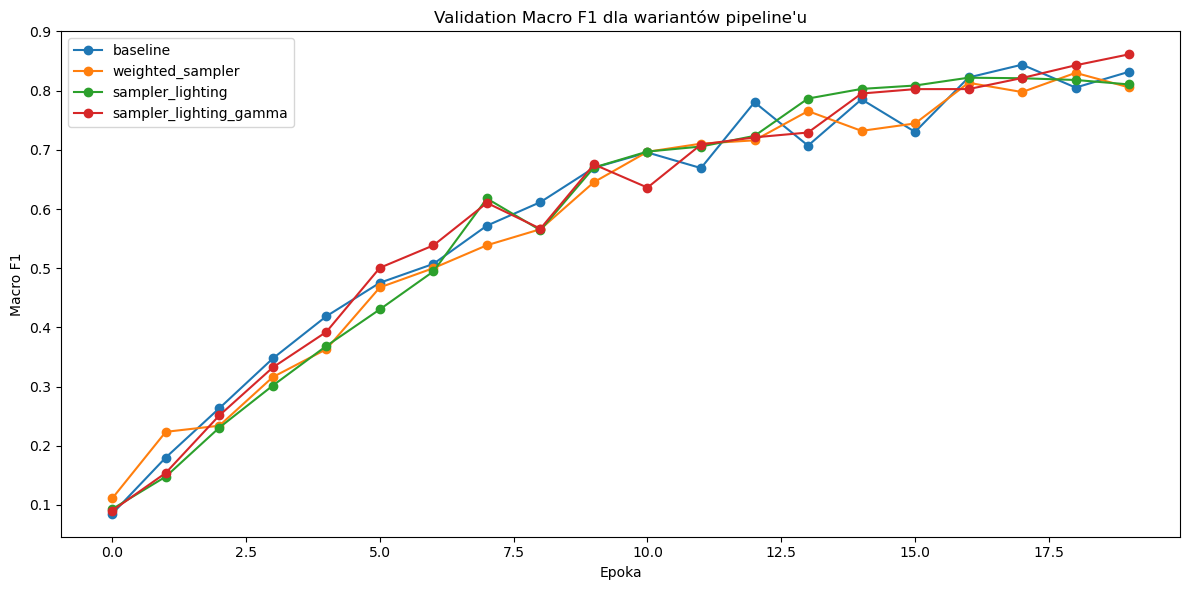

In [12]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)


for experiment_name in EXPERIMENTS:

    history = (
        experiments_history[
            experiment_name
        ]
    )


    ax.plot(
        history[
            "val_macro_f1"
        ],
        marker="o",
        label=experiment_name,
    )


ax.set_title(
    "Validation Macro F1 "
    "dla wariantów pipeline'u"
)


ax.set_xlabel(
    "Epoka"
)


ax.set_ylabel(
    "Macro F1"
)


ax.legend()


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_ablation_macro_f1_history.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 10. Porównanie standardowego Macro F1

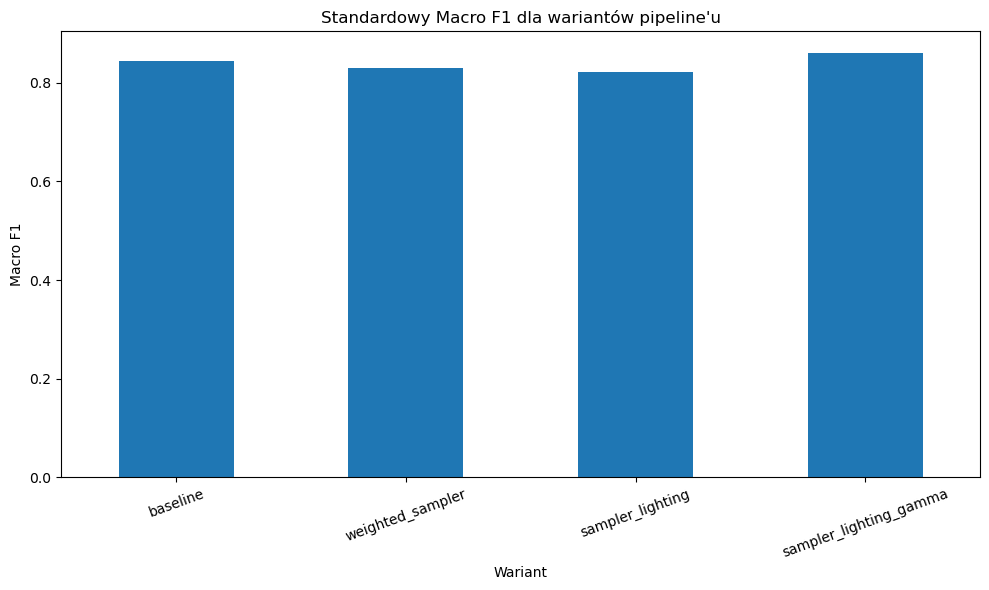

In [13]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)


plot_data = (
    ablation_results_df
    .set_index(
        "experiment"
    )[
        "macro_f1"
    ]
    .reindex(
        EXPERIMENTS
    )
)


plot_data.plot(
    kind="bar",
    ax=ax,
)


ax.set_title(
    "Standardowy Macro F1 "
    "dla wariantów pipeline'u"
)


ax.set_xlabel(
    "Wariant"
)


ax.set_ylabel(
    "Macro F1"
)


plt.xticks(
    rotation=20
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "02_ablation_standard_macro_f1.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 11. Przygotowanie funkcji do testu odporności na oświetlenie

Po ocenie standardowej skuteczności każdy wariant zostanie dodatkowo oceniony na kontrolowanych wariantach zaciemnienia.

Ocena jest wykonywana wyłącznie na zbiorze walidacyjnym.

In [14]:
def evaluate_lighting_variant(
    model,
    variant,
):

    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=eval_transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

## 12. Odporność poszczególnych wariantów na zaciemnienie

In [15]:
dark_results = []


for experiment_index, experiment_name in enumerate(
    EXPERIMENTS
):

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"custom_cnn_ablation_{experiment_name}.pt"
    )


    model = create_custom_cnn(
        num_classes=NUM_CLASSES
    ).to(
        DEVICE
    )


    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )


    if (
        isinstance(
            checkpoint,
            dict,
        )
        and "model_state_dict"
        in checkpoint
    ):

        model.load_state_dict(
            checkpoint[
                "model_state_dict"
            ]
        )

    else:

        model.load_state_dict(
            checkpoint
        )


    model.eval()


    for variant in DARK_VARIANTS:

        print(
            f"{experiment_name} | {variant}"
        )


        metrics = (
            evaluate_lighting_variant(
                model,
                variant,
            )
        )


        dark_results.append(
            {
                "experiment":
                    experiment_name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                **metrics,
            }
        )


dark_results_df = pd.DataFrame(
    dark_results
)


display(
    dark_results_df
)


dark_results_df.to_csv(
    METRICS_DIR
    / "custom_cnn_pipeline_ablation_dark_results.csv",
    index=False,
    encoding="utf-8-sig",
)

baseline | dark_1
baseline | dark_2
baseline | dark_3
weighted_sampler | dark_1
weighted_sampler | dark_2
weighted_sampler | dark_3
sampler_lighting | dark_1
sampler_lighting | dark_2
sampler_lighting | dark_3
sampler_lighting_gamma | dark_1
sampler_lighting_gamma | dark_2
sampler_lighting_gamma | dark_3


,experiment,variant,factor,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,baseline,dark_1,0.7,0.897293,0.832175,0.773565,0.780038,57.127212
1,baseline,dark_2,0.5,0.828822,0.749707,0.644127,0.659107,54.266629
2,baseline,dark_3,0.3,0.673965,0.592426,0.433077,0.454447,55.986664
3,weighted_sampler,dark_1,0.7,0.798567,0.756650,0.797680,0.738395,56.737974
4,weighted_sampler,dark_2,0.5,0.695064,0.702432,0.684910,0.635792,58.499679
5,weighted_sampler,dark_3,0.3,0.482882,0.596349,0.447590,0.414357,58.732269
6,sampler_lighting,dark_1,0.7,0.808917,0.772573,0.842317,0.776604,51.500253
7,sampler_lighting,dark_2,0.5,0.721338,0.719656,0.759416,0.693328,51.531686
8,sampler_lighting,dark_3,0.3,0.474124,0.662516,0.518725,0.489017,51.021948
9,sampler_lighting_gamma,dark_1,0.7,0.881369,0.863653,0.879917,0.853499,53.491061


## 13. Podsumowanie odporności na zaciemnienie

In [16]:
dark_summary = (
    dark_results_df
    .groupby(
        "experiment"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),

        dark3_macro_f1=(
            "macro_f1",
            lambda values:
                values.iloc[-1],
        ),
    )
    .reset_index()
)


standard_f1 = (
    ablation_results_df[
        [
            "experiment",
            "macro_f1",
        ]
    ]
    .rename(
        columns={
            "macro_f1":
                "standard_macro_f1"
        }
    )
)


dark_summary = (
    dark_summary
    .merge(
        standard_f1,
        on="experiment",
    )
)


dark_summary[
    "f1_drop_to_dark3"
] = (
    dark_summary[
        "standard_macro_f1"
    ]
    -
    dark_summary[
        "dark3_macro_f1"
    ]
)


dark_summary = (
    dark_summary[
        [
            "experiment",
            "standard_macro_f1",
            "mean_dark_macro_f1",
            "mean_dark_accuracy",
            "dark3_macro_f1",
            "f1_drop_to_dark3",
        ]
    ]
)


display(
    dark_summary
)


dark_summary.to_csv(
    METRICS_DIR
    / "custom_cnn_pipeline_ablation_dark_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,experiment,standard_macro_f1,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,f1_drop_to_dark3
0,baseline,0.843946,0.631197,0.800027,0.454447,0.389499
1,sampler_lighting,0.821927,0.652983,0.668126,0.489017,0.332910
2,sampler_lighting_gamma,0.861453,0.770538,0.807988,0.658705,0.202748
3,weighted_sampler,0.830093,0.596181,0.658838,0.414357,0.415736


## 14. Porównanie odporności na zaciemnienie

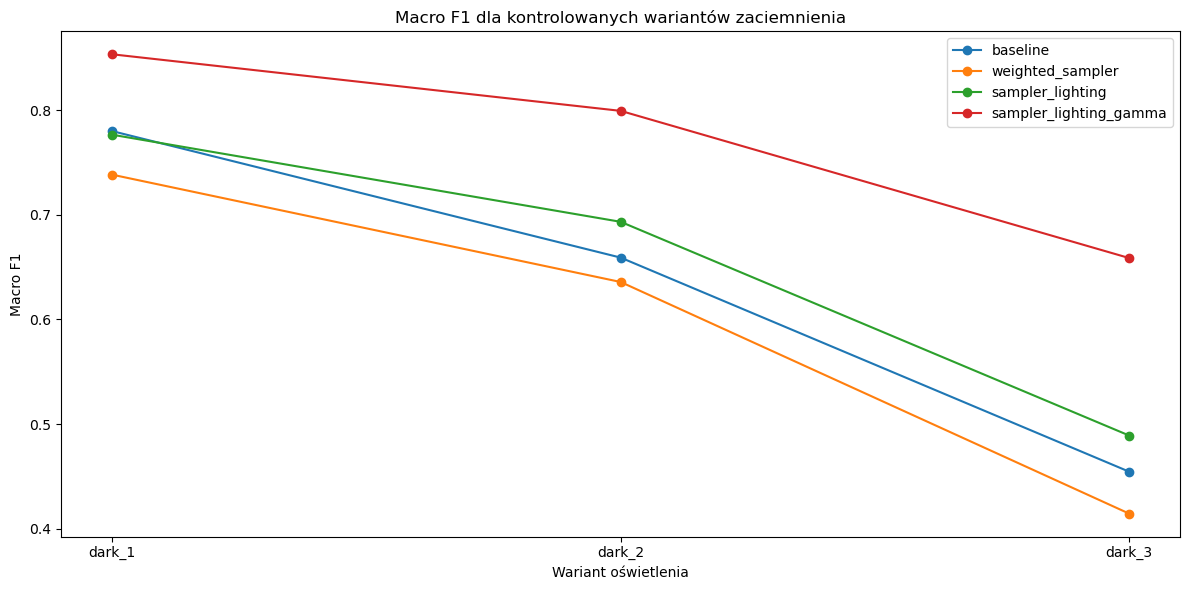

In [17]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)


for experiment_name in EXPERIMENTS:

    subset = (
        dark_results_df[
            dark_results_df[
                "experiment"
            ]
            == experiment_name
        ]
    )


    ax.plot(
        subset[
            "variant"
        ],
        subset[
            "macro_f1"
        ],
        marker="o",
        label=experiment_name,
    )


ax.set_title(
    "Macro F1 dla kontrolowanych "
    "wariantów zaciemnienia"
)


ax.set_xlabel(
    "Wariant oświetlenia"
)


ax.set_ylabel(
    "Macro F1"
)


ax.legend()


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "03_ablation_dark_robustness.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 15. Wybór konfiguracji pipeline'u

In [18]:
comparison_df = (
    ablation_results_df[
        [
            "experiment",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "training_time_seconds",
            "inference_time_seconds",
            "parameters",
        ]
    ]
    .rename(
        columns={
            "macro_f1":
                "standard_macro_f1"
        }
    )
)


comparison_df = (
    comparison_df
    .merge(
        dark_summary[
            [
                "experiment",
                "mean_dark_macro_f1",
                "mean_dark_accuracy",
                "dark3_macro_f1",
                "f1_drop_to_dark3",
            ]
        ],
        on="experiment",
    )
)


display(
    comparison_df
)


comparison_df.to_csv(
    METRICS_DIR
    / "custom_cnn_pipeline_ablation_full_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

,experiment,accuracy,macro_precision,macro_recall,standard_macro_f1,training_time_seconds,inference_time_seconds,parameters,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,f1_drop_to_dark3
0,sampler_lighting_gamma,0.889729,0.873810,0.885688,0.861453,16166.307191,49.614171,413020,0.770538,0.807988,0.658705,0.202748
1,baseline,0.940287,0.889067,0.830464,0.843946,16296.736155,48.181454,413020,0.631197,0.800027,0.454447,0.389499
2,weighted_sampler,0.871815,0.829798,0.878583,0.830093,15539.103524,48.206727,413020,0.596181,0.658838,0.414357,0.415736
3,sampler_lighting,0.859475,0.815060,0.873608,0.821927,15524.865617,48.163053,413020,0.652983,0.668126,0.489017,0.332910


In [19]:
best_standard = (
    comparison_df.loc[
        comparison_df[
            "standard_macro_f1"
        ].idxmax()
    ]
)


best_dark = (
    comparison_df.loc[
        comparison_df[
            "mean_dark_macro_f1"
        ].idxmax()
    ]
)


best_dark3 = (
    comparison_df.loc[
        comparison_df[
            "dark3_macro_f1"
        ].idxmax()
    ]
)


best_stability = (
    comparison_df.loc[
        comparison_df[
            "f1_drop_to_dark3"
        ].idxmin()
    ]
)


print(
    "Najlepszy standardowy Macro F1:",
    best_standard["experiment"],
    f"({best_standard['standard_macro_f1']:.4f})",
)


print(
    "Najlepszy średni dark Macro F1:",
    best_dark["experiment"],
    f"({best_dark['mean_dark_macro_f1']:.4f})",
)


print(
    "Najlepszy dark_3 Macro F1:",
    best_dark3["experiment"],
    f"({best_dark3['dark3_macro_f1']:.4f})",
)


print(
    "Najmniejszy spadek F1:",
    best_stability["experiment"],
    f"({best_stability['f1_drop_to_dark3']:.4f})",
)

Najlepszy standardowy Macro F1: sampler_lighting_gamma (0.8615)
Najlepszy średni dark Macro F1: sampler_lighting_gamma (0.7705)
Najlepszy dark_3 Macro F1: sampler_lighting_gamma (0.6587)
Najmniejszy spadek F1: sampler_lighting_gamma (0.2027)


In [20]:
final_ablation_summary = (
    comparison_df.copy()
)


final_ablation_summary.to_csv(
    METRICS_DIR
    / "custom_cnn_pipeline_ablation_final_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


print(
    "Wyniki zapisano w:"
)

print(
    METRICS_DIR
    / "custom_cnn_pipeline_ablation_final_summary.csv"
)

Wyniki zapisano w:
C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\results\metrics\custom_cnn_pipeline_ablation_final_summary.csv
